# Day 1 — What If You Could Teach a Computer to Think?

Welcome to Day 1 of the Deep Learning Summer School!

Today we go from *zero* to a working neural network. By the end of the day you will have:

1. Understood how neural networks are **inspired by biology** — and where the analogy ends
2. Learned the language of deep learning: **tensors, gradients, activations, losses and optimisers**
3. Built and trained your **first neural network from scratch** in PyTorch
4. Trained a multi-layer network that recognises **handwritten digits** with ~95% accuracy

Theory meets code, from day one.

---

## From Biology to Silicon

Your brain contains roughly 86 billion **neurons**. Each one is simple: it receives electrical signals
from other neurons through its *dendrites*, sums them up in the cell body, and — if the combined signal
crosses a threshold — *fires*, sending a signal down its *axon* to thousands of other neurons.
Intelligence emerges not from any single neuron, but from the **connections** between them
(the *synapses*), which strengthen and weaken as you learn.

In 1943, McCulloch & Pitts asked: *what if we modelled this mathematically?* The result is the
**artificial neuron**:

- inputs $x_1, x_2, \dots$ play the role of incoming signals
- **weights** $w_1, w_2, \dots$ play the role of synapse strengths (these are what the network *learns*)
- a **bias** $b$ shifts the firing threshold
- an **activation function** decides whether (and how strongly) the neuron "fires"

$$\text{output} = \text{activation}(w_1 x_1 + w_2 x_2 + \dots + b)$$

Stack thousands of these neurons into **layers**, connect the layers, and you have a *neural network*.
The analogy with biology is loose — real neurons are far more complicated — but it gave us the right
building block. Let's see what these networks can do.

# Neural Network Basics

We'll look at how a Neural Network is trained, and learn some terminologies associated with the process.

Then we'll look at some important hyperparameters associated with Neural Networks:
- Activation Functions
- Loss Functions
- Optimisers

## Training a Neural Network

Let us watch [this short clip](https://www.youtube.com/watch?v=bfmFfD2RIcg&t=36s) on the training process of a Neural Network.

In summary, the following steps are done:

<div style="text-align: center"><img src="train_nn.png" width="600"/></div>



# Deep Learning vs Machine Learning


<div style="text-align: center"><img src="DL_in_ML.png" width="300"/></div>

Deep Learning is a branch of Machine Learning.

Machine Learning is one of the approaches to Artificial Intelligence.

Artificial Intelligence is a research branch of Computer Science.

<div style="text-align: center"><img src="ML_vs_DL.png" width="450"/></div>

Where DL hence gains an advantage is in situations where the problem is too complex to easily define suitable features. Sometimes (like in language processing, for example) it's difficult to even imagine what those features may be.

# The effect of each component in a Neural Network

<div style="text-align: center"><img src="neuron.png" width="700"/></div>

- the weight determines the initial value (importance of neuron output/input)
- the bias shifts the line up or down
- the activation function allows the line to be bent into any shape we want
- the connection (i.e. multiple neurons coming together) allows for joining of the lines into a final shape/envelope

See below how the two neurons in the layer (blue and orange) both fine tune the inputs to their respective activation functions, which then get scaled and combined to form the desired green line

Screenshots source: [The Essential Main Ideas of Neural Networks - YouTube](https://www.youtube.com/watch?v=CqOfi41LfDw)


<div style="text-align: center"><img src="NN_layers1.png" width="700"/></div>

<div style="text-align: center"><img src="NN_layers2.png" width="700"/></div>


---

# Our Tool: PyTorch

Theory is nothing without code. To build networks we'll use **PyTorch**, the most widely used
deep learning framework in research. The crash course below covers everything we need today:
tensors (the data structure of deep learning), autograd (automatic differentiation — the engine
that makes learning possible), and the training loop.

> Want to go deeper on tensors? See `extras/Tensors.ipynb` in today's folder for a full deep dive,
> and `extras/activations.ipynb` for a side-by-side comparison of activation functions.

# PyTorch Crash Course

Before we begin, you first need to be familiar with a few neural network basic concepts. See the included _NN_basics.ipynb_ notebook for those.

#### Overview:

1. Some Tensor Basics
  - Creating tensors, Basic operations, Converting from NumPy & vice versa, leveraging GPUs
2. Autograd
  - Using it to calculate & track gradients (differentiations during backpropagation)
3. Training a Neural Network
  - Build a Linear regression example to see how to do Gradient Descent using Autograd
4. Using the In-built Model, Loss & Optimizer
  - Utilising the in-built functions to make model crafting & training easier
  - A typical PyTorch training pipeline
5. Multi-Layer Network
  - Leveraging GPUs, Utilising standard Datasets, Batching with the DataLoader, Applying Transforms & Model Evaluation
6. Saving the Model
  - Both for inference and further training

## 1. Tensors

Everything in PyTorch is based on Tensor operations. A Tensor is a multi-dimensional matrix containing elements of a single data type.

Here's we'll look a few useful basics of tensors. For more about tensors - check out the included _Tensors.ipynb_ notebook


In [1]:
import torch

# torch.empty(size): uninitiallized
x = torch.empty(1) # scalar
print("empty(1):", x)
x = torch.empty(3) # vector
print("empty(3):",x)
x = torch.empty(2, 3) # matrix
print("empty(2,3):",x)
x = torch.empty(2, 2, 3) # tensor, 3 dimensions
#x = torch.empty(2,2,2,3) # tensor, 4 dimensions
print("empty(2, 2, 3):",x)

# torch.rand(size): random numbers [0, 1]
x = torch.rand(5, 3)
print("rand(5,3):", x)

# torch.zeros(size), fill with 0
# torch.ones(size), fill with 1
x = torch.zeros(5, 3)
print("zeros(5,3):", x)

empty(1): tensor([0.])
empty(3): tensor([0., 0., 0.])
empty(2,3): tensor([[0., 0., 0.],
        [0., 0., 0.]])
empty(2, 2, 3): tensor([[[0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.]]])
rand(5,3): tensor([[0.9514, 0.5566, 0.9823],
        [0.1604, 0.9634, 0.3163],
        [0.4943, 0.3254, 0.8079],
        [0.6308, 0.1362, 0.9852],
        [0.7146, 0.1168, 0.3904]])
zeros(5,3): tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [40]:
# check size
print("size", x.size())  # x.size(0)
print("shape", x.shape)  # x.shape[0]

size torch.Size([5, 3])
shape torch.Size([5, 3])


In [41]:
# check data type
print(x.dtype)

# specify types, float32 default
x = torch.zeros(5, 3, dtype=torch.float16)
print(x)

# check type
print(x.dtype)

torch.float32
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=torch.float16)
torch.float16


In [42]:
# construct from data
x = torch.tensor([5.5, 3])
print(x, x.dtype)

tensor([5.5000, 3.0000]) torch.float32


In [43]:
# requires_grad argument
# This will tell pytorch that it will need to calculate the gradients for this tensor
# later in your optimization steps
# i.e. this is a variable in your model that you want to optimize
x = torch.tensor([5.5, 3], requires_grad=True)
print(x)

tensor([5.5000, 3.0000], requires_grad=True)


#### Operations with Tensors

In [44]:
# Operations
x = torch.ones(2, 2)
y = torch.rand(2, 2)

# elementwise addition
z = x + y
# torch.add(x,y)

# in place addition, everythin with a trailing underscore is an inplace operation
# i.e. it will modify the variable
# y.add_(x)

print(x)
print(y)
print(z)

tensor([[1., 1.],
        [1., 1.]])
tensor([[0.7093, 0.0483],
        [0.3923, 0.7595]])
tensor([[1.7093, 1.0483],
        [1.3923, 1.7595]])


In [45]:
# subtraction
z = x - y
z = torch.sub(x, y)

# multiplication
z = x * y
z = torch.mul(x,y)

# division
z = x / y
z = torch.div(x,y)

In [46]:
# Slicing
x = torch.rand(5,3)
print(x)
print("x[:, 0]", x[:, 0]) # all rows, column 0
print("x[1, :]", x[1, :]) # row 1, all columns
print("x[1, 1]", x[1,1]) # element at 1, 1

# Get the actual value if only 1 element in your tensor
print("x[1,1].item()", x[1,1].item())

tensor([[0.5734, 0.3796, 0.9071],
        [0.3609, 0.9674, 0.0444],
        [0.8965, 0.7300, 0.0335],
        [0.3632, 0.2111, 0.4294],
        [0.5268, 0.1169, 0.0169]])
x[:, 0] tensor([0.5734, 0.3609, 0.8965, 0.3632, 0.5268])
x[1, :] tensor([0.3609, 0.9674, 0.0444])
x[1, 1] tensor(0.9674)
x[1,1].item() 0.9674456715583801


In [47]:
# Reshape with torch.view()
x = torch.randn(4, 4)
y = x.view(16)
z = x.view(-1, 8)  # the size -1 is inferred from other dimensions
# if -1 it pytorch will automatically determine the necessary size
print(x.size(), y.size(), z.size())

torch.Size([4, 4]) torch.Size([16]) torch.Size([2, 8])


#### NumPy

Converting a Torch Tensor to a NumPy array and vice versa is very easy

In [48]:
a = torch.ones(5)
print(a)

# torch to numpy with .numpy()
b = a.numpy()
print(b)
print(type(b))

tensor([1., 1., 1., 1., 1.])
[1. 1. 1. 1. 1.]
<class 'numpy.ndarray'>


In [49]:
# Careful: If the Tensor is on the CPU (not the GPU),
# both objects will share the same memory location, so changing one
# will also change the other
a.add_(1)
print(a)
print(b)

tensor([2., 2., 2., 2., 2.])
[2. 2. 2. 2. 2.]


In [2]:
# numpy to torch with .from_numpy(x), or torch.tensor() to copy it
import numpy as np
a = np.ones(5)
b = torch.from_numpy(a)
c = torch.tensor(a)
# print(a)
# print(b)
# print(c)

# again be careful when modifying
a += 1
print(a)
print(b)
print(c)

[2. 2. 2. 2. 2.]
tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
tensor([1., 1., 1., 1., 1.], dtype=torch.float64)


#### GPU Support

First, check if GPU is available

In [51]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # check if NVIDIA GPU is available on Windows or Linux
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu') # check if MPS (Metal Performance Shaders) is available on MacOS
# if multiple GPUs are available, you can specify the GPU number
# device = torch.device('cuda:0') # first GPU
# device = torch.device('cuda:1') # second GPU
print(device)

mps


By default all tensors are created on the CPU. But we can also move them to the GPU, or create them directly on the GPU.

In [52]:

x = torch.rand(2,2).to(device)  # move tensors to GPU device
#x = x.to("cpu")
#x = x.to("cuda")

x = torch.rand(2,2, device=device)  # or directy create them on GPU

## 2. Autograd

The autograd package provides automatic differentiation for all operations on Tensors. Generally speaking, *torch.autograd* is an engine for computing the vector-Jacobian product. It computes partial derivates while applying the chain rule.

Set `requires_grad = True`: This allows us to track the operations on the tensor in a Computational Graph

In [8]:
import torch

# requires_grad = True -> tracks all operations on the tensor.
x = torch.randn(3, requires_grad=True)
y = x + 2

# y was created as a result of an operation, so it has a grad_fn attribute.
# grad_fn: references a Function that has created the Tensor
print(x) # created by the user -> grad_fn is None
print(y)
print(y.grad_fn)

tensor([ 0.4301,  0.5816, -0.9710], requires_grad=True)
tensor([2.4301, 2.5816, 1.0290], grad_fn=<AddBackward0>)


In [9]:
# Do more operations on y
z = y * y * 3
print(z)
z = z.mean()
print(z)

tensor([17.7154, 19.9936,  3.1767], grad_fn=<MulBackward0>)
tensor(13.6286, grad_fn=<MeanBackward0>)


Let's compute the gradients with backpropagation

When we finish our computation we can call .backward() and have all the gradients computed automatically.

The gradient for this tensor will be accumulated into .grad attribute.

It is the partial derivate of the function w.r.t. the tensor

In [10]:
#backpropagation

print(x.grad)
z.backward()
print(x.grad) # dz/dx

# !!! Careful!!! backward() accumulates the gradient for this tensor into .grad attribute.
# !!! We need to be careful during optimization !!! optimizer.zero_grad()

None
tensor([4.8601, 5.1631, 2.0581])


#### Stop a tensor from tracking history:
For example during the training loop when we want to update our weights, or after training during evaluation. These operations should not be part of the gradient computation. To prevent this, we can use:

- `x.requires_grad_(False)`
- `x.detach()`
- wrap in `with torch.no_grad():`

In [56]:
# .requires_grad_(...) changes an existing flag in-place.
a = torch.randn(2, 2)
b = (a * a).sum()
print(a.requires_grad)
print(b.grad_fn)

a.requires_grad_(True)
b = (a * a).sum()
print(a.requires_grad)
print(b.grad_fn)

False
None
True


In [57]:
# .detach(): get a new Tensor with the same content but no gradient computation:
a = torch.randn(2, 2, requires_grad=True)
b = a.detach()
print(a.requires_grad)
print(b.requires_grad)

True
False


In [58]:
# wrap in 'with torch.no_grad():'
a = torch.randn(2, 2, requires_grad=True)
print(a.requires_grad)
with torch.no_grad():
    b = a ** 2
    print(b.requires_grad)

True
False


# 3. Training a Neural Network
We learn how to implement Gradient Descent using Autograd using Linear Regression as an example:

$f(x) = w * x + b$

here : `f(x) = 2 * x`

In [59]:
import torch

# train data
X = torch.tensor([1, 2, 3, 4, 5, 6, 7, 8], dtype=torch.float32)
Y = torch.tensor([2, 4, 6, 8, 10, 12, 14, 16], dtype=torch.float32)

# initialize weights
w = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)

# model output
def forward(x):
    return w * x

# loss = MSE
def loss(y, y_pred):
    return ((y_pred - y)**2).mean()

X_test = 5.0

print(f'Prediction before training: f({X_test}) = {forward(X_test).item():.3f}')

Prediction before training: f(5.0) = 0.000


In [60]:
# Training
learning_rate = 0.01
n_epochs = 100

for epoch in range(n_epochs):
    # predict = forward pass
    y_pred = forward(X)

    # loss
    l = loss(Y, y_pred)

    # calculate gradients = backward pass
    l.backward()

    # update weights
    #w.data = w.data - learning_rate * w.grad
    with torch.no_grad():
      w -= learning_rate * w.grad # this is the formula for gradient descent (w = w - learning_rate * gradient)

    # zero the gradients after updating
    w.grad.zero_()

    if (epoch+1) % 10 == 0:
        print(f'epoch {epoch+1}: w = {w.item():.3f}, loss = {l.item():.3f}')

print(f'Prediction after training: f({X_test}) = {forward(X_test).item():.3f}')

epoch 10: w = 1.998, loss = 0.000
epoch 20: w = 2.000, loss = 0.000
epoch 30: w = 2.000, loss = 0.000
epoch 40: w = 2.000, loss = 0.000
epoch 50: w = 2.000, loss = 0.000
epoch 60: w = 2.000, loss = 0.000
epoch 70: w = 2.000, loss = 0.000
epoch 80: w = 2.000, loss = 0.000
epoch 90: w = 2.000, loss = 0.000
epoch 100: w = 2.000, loss = 0.000
Prediction after training: f(5.0) = 10.000


---

We just trained our first "network" — a single weight! — using gradient descent. Before scaling up,
we need to choose two things for any real network: the **activation functions** that give it the power
to model non-linear patterns, and the **loss function** that defines what "good" means.

# Activation Functions

Here's the model equation for each neuron:

<div style="text-align: center"><img src="activation.png" width="600"/></div>

-	Without ⍺: You only get linear mappings, even with many layers.
-	With ⍺: You get universal approximation—the network can model almost any function with enough neurons/layers.


| Component         | Role                            | Effect on Function                  |
|------------------|----------------------------------|-------------------------------------|
| **Weights (W)**  | Scale input                      | Controls the slope of the line      |
| **Bias (b)**     | Offset                           | Shifts the function                 |
| **Activation (⍺)**| Introduce nonlinearity          | Enables modeling of complex patterns|


So, it’s the activation function that really upgrades a linear function into something more expressive. 
The weights and biases adjust and tune the inputs so that when passed through the nonlinear activation, the network can approximate complex functions.

Let's look at a few of the most common activation functions.



## Logistic Activation Function (Sigmoid)
The logistic function which is a commonly used activation function in neural networks and also known as the sigmoid function. It takes any input and **maps it to a value between 0 and 1**, which can be interpreted as a probability. This makes it particularly useful for binary classification tasks, where the network needs to predict the probability of an input belonging to one of two classes.

One of the main advantages of the logistic function is that it is differentiable, which means that it can be used in backpropagation algorithms to train the neural network. Additionally, it has a smooth gradient, which can help avoid issues such as exploding gradients.

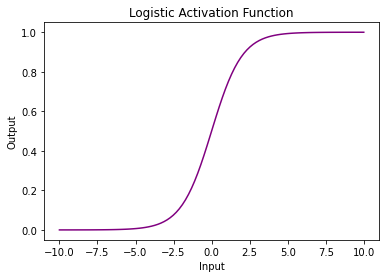

In [1]:
# importing the libraries
import torch
import matplotlib.pyplot as plt

# create a PyTorch tensor
x = torch.linspace(-10, 10, 100)

# apply the logistic activation function to the tensor
y = torch.sigmoid(x)

# plot the results with a custom color
plt.plot(x.numpy(), y.numpy(), color='purple')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Logistic Activation Function')
plt.show()

## Tanh Activation Function

The tanh activation function which **outputs values between -1 and 1**, with a mean output of 0. This can help ensure that the output of a neural network layer remains **centered around 0**, making it useful for normalization purposes. Tanh is a smooth and continuous activation function, which makes it easier to optimize during the process of gradient descent.

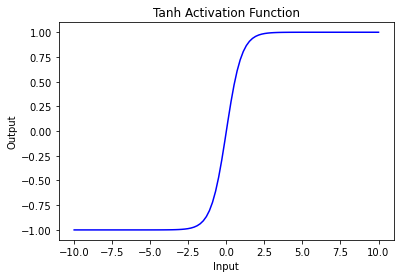

In [2]:
# apply the tanh activation function to the tensor
y = torch.tanh(x)

# plot the results with a custom color
plt.plot(x.numpy(), y.numpy(), color='blue')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Tanh Activation Function')
plt.show()

### Sigmoid vs Tanh

Tanh converges faster due to higher max derivative

<div style="text-align: center"><img src="max_dir.png" width="400"/></div>

But, due to the use of exponential functions, tanh can be computationally expensive, especially for large tensors or when used in deep neural networks with many layers.




### The Issue with sigmoid and tanh

Like the logistic activation function, the tanh function can be susceptible to the vanishing gradient problem, especially for deep neural networks with many layers. This is because the slope of the function becomes very small for large or small input values, making it difficult for gradients to propagate through the network.

<div style="text-align: center"><img src="Vanishing_gradient_prob.png" width="600"/></div>


## ReLU Activation Function
ReLU (Rectified Linear Unit) is another commonly used activation function in neural networks. 

Unlike the sigmoid and tanh functions, ReLU is **a non-saturating function**, which means that it does not become flat at the extremes of the input range. Instead, ReLU simply **outputs the input value if it is positive, or 0 if it is negative**.

This simple, piecewise linear function has several advantages over sigmoid and tanh activation functions:
- First, it is computationally more efficient, making it well-suited for large-scale neural networks. 
- Second, ReLU has been shown to be less susceptible to the vanishing gradient problem, as it does not have a flattened slope. 
- Plus, ReLU can help sparsify the activation of neurons in a network, which can lead to better generalization

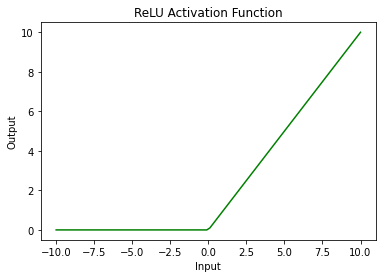

In [4]:
# apply the ReLU activation function to the tensor
y = torch.relu(x)

# plot the results with a custom color
plt.plot(x.numpy(), y.numpy(), color='green')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('ReLU Activation Function')
plt.show()

# ReLU alternatives

In some (rare cases), our neuron can reach a "dead state" where it only outputs zeros.

Alternatives to avoid "dying ReLU" problem therefore exist.

<div style="text-align: center"><img src="2_ReLU_alts.png" width="600"/></div>

We we will look into how these all compare to each other in the second workshop

# Using Activation Functions at the Output Layer

## Linear Regression
Do Not Use an Activation Function for linear problems

<div style="text-align: center"><img src="lin_reg_act.png" width="600"/></div>

## Multiclass Problems

You can use sigmoid for binary classification problems but not for multi-class

<div style="text-align: center"><img src="multi_sig.png" width="600"/></div>

Instead, we can use **softmax**. This function **convert values into probabilities**

<div style="text-align: center"><img src="softmax_prob.png" width="600"/></div>

Taking the exponent is better than just doing ordinary averages, as it makes the larger values larger and smaller values much smaller

<div style="text-align: center"><img src="exp_vs_raw.png" width="600"/></div>

Another similar function is **argmax**, which basically returns the node with the highest value


# Loss Functions

There's a lot of loss functions in PyTorch, and you can even craft your own.
Let's look at a few of the most common ones, but you can read about others and when to use them [here](https://medium.com/@AIchemizt/types-of-loss-functions-in-machine-learning-and-their-usage-d4594e1529d2).

### MAE & MSE
In PyTorch, you can create MAE and MSE as loss functions using nn.L1Loss() and nn.MSELoss() respectively. It is named as L1 because the computation of MAE is also called the L1-norm in mathematics. 

Below is an example of computing the MAE and MSE between two vectors



In [11]:
import torch
import torch.nn as nn

mae = nn.L1Loss()
mse = nn.MSELoss()

predict = torch.tensor([0., 3.])
target = torch.tensor([1., 0.])

print("MAE: %.3f" % mae(predict, target))
print("MSE: %.3f" % mse(predict, target))

MAE: 2.000
MSE: 5.000


### Cross-Entropy
In PyTorch, the cross-entropy function is provided by nn.CrossEntropyLoss(). 

It takes the predicted logits and the target as parameter and compute the categorical cross-entropy. 

NOTE!: Inside the CrossEntropyLoss() function, softmax will be applied to the logits hence you should not use softmax activation function at the output layer. 

An example of using the cross entropy loss function from PyTorch is shown below:

In [12]:
import torch
import torch.nn as nn

ce = nn.CrossEntropyLoss()

logits = torch.tensor([[-1.90, -0.29, -2.30], [-0.29, -1.90, -2.30]])
target = torch.tensor([[0., 1., 0.], [1., 0., 0.]])
print("Cross entropy: %.3f" % ce(logits, target))

Cross entropy: 0.288


Note the first argument to the cross entropy loss function is logit, not probabilities. Hence each row does not sum to 1. 

The second argument, however, is a tensor containing rows of probabilities. 

If you convert the logits tensor above into probability using softmax function, it would be:

In [ ]:
probs = torch.tensor([[0.15, 0.75, 0.1], [0.75, 0.15, 0.1]])

# after applying softmax
logits = torch.log(probs)
print("Cross entropy: %.3f" % ce(logits, target)) #negative log of 0.75 is 0.2877

Cross entropy: 0.288


Note in PyTorch, you can use nn.LogSoftmax() as an activation function. 

It applies softmax on the output of a layer and than take the logarithm on each element. 

If this is your output layer, you should use nn.NLLLoss() (negative log likelihood) as the loss function. 

Mathematically this combination is same as cross entropy loss. 
You can confirm this by checking the code below produced the same output:

In [14]:
import torch
import torch.nn as nn

ce = nn.NLLLoss()

# softmax to apply on dimension 1, i.e. per row
logsoftmax = nn.LogSoftmax(dim=1)

logits = torch.tensor([[-1.90, -0.29, -2.30], [-0.29, -1.90, -2.30]])
pred = logsoftmax(logits)
indices = torch.tensor([1, 0])
print("Cross entropy: %.3f" % ce(pred, indices))

Cross entropy: 0.288


In case of a classification problem with only two classes, it becomes binary classification. It is special because the model is now a logistic regression model in which there can be only one output instead of a vector of two values. You can still implement binary classification as multiclass classification and use the same cross entropy function. But if you output *x* as the probability (between 0 and 1) for the “positive class”, it is known that the probability for the “negative class” must be *1-x*.

In PyTorch, you have nn.BCELoss() for binary cross entropy. It is specialized for binary case:

In [15]:
import torch
import torch.nn as nn

bce = nn.BCELoss()

pred = torch.tensor([0.75, 0.25])
target = torch.tensor([1., 0.])
print("Binary cross entropy: %.3f" % bce(pred, target))

Binary cross entropy: 0.288


## When to use which?

**Regression Problem**:

A problem where you predict a real-value quantity.

- Output Layer Configuration: One node with a linear activation unit.
- Loss Function: Mean Squared Error (MSE).

**Binary Classification Problem** 

A problem where you classify an example as belonging to one of two classes.

The problem is framed as predicting the likelihood of an example belonging to class one, e.g. the class that you assign the integer value 1, whereas the other class is assigned the value 0.

- Output Layer Configuration: One node with a sigmoid activation unit.
- Loss Function: Cross-Entropy, also referred to as Logarithmic loss.

**Multi-Class Classification Problem**

A problem where you classify an example as belonging to one of more than two classes.

The problem is framed as predicting the likelihood of an example belonging to each class.

- Output Layer Configuration: One node for each class using the softmax activation function.
- Loss Function: Cross-Entropy, also referred to as Logarithmic loss.

# 4. Using the In-built Model, Loss & Optimizer
Let's learn how to utilise the in-built functions to make this easier

A typical PyTorch pipeline looks like this:

1. Design model (input, output, forward pass with different layers)
2. Construct loss and optimizer
3. Training loop:
  - Forward = compute prediction and loss
  - Backward = compute gradients
  - Update weights

In [61]:
import torch
import torch.nn as nn # Neural Networks Module needed this time

# Linear regression
# f = w * x
# here : f = 2 * x

0) Create Training Samples (will see later how to import stuff)

In [ ]:
# Watch the shape! 
# Inner bracket coz Tensor expects 2D (n_samples, n_features)
X = torch.tensor([[1], [2], [3], [4], [5], [6], [7], [8]], dtype=torch.float32)
Y = torch.tensor([[2], [4], [6], [8], [10], [12], [14], [16]], dtype=torch.float32)

n_samples, n_features = X.shape
print(f'n_samples = {n_samples}, n_features = {n_features}')

# 0) create a test sample
X_test = torch.tensor([5], dtype=torch.float32)

n_samples = 8, n_features = 1


1) Design Model, the model has to implement the forward pass!

In [67]:
# Here we can simply use a built-in model from PyTorch
# model = nn.Linear(input_size, output_size)

class LinearRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegression, self).__init__() #! Remember to call the parent class constructor
        # define different layers
        self.lin = nn.Linear(input_dim, output_dim) #does w * x + b, you can also set bias=False but ignored for our case coz I want to keep it simple

    def forward(self, x):
        return self.lin(x)


input_size, output_size = n_features, n_features

model = LinearRegression(input_size, output_size)

print(f'Prediction before training: f({X_test.item()}) = {model(X_test).item():.3f}')



Prediction before training: f(5.0) = -2.893


2) Define loss and optimizer

In [68]:
# arbitrary numbers for now
learning_rate = 0.01
n_epochs = 100

loss = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

3) Training loop

In [ ]:
# Training
for epoch in range(n_epochs):
    # predict = forward pass with our model
    y_predicted = model(X)

    # loss
    l = loss(Y, y_predicted)

    # calculate gradients = backward pass
    l.backward()

    # update weights
    optimizer.step()

    # zero the gradients after updating
    optimizer.zero_grad()

    if (epoch+1) % 10 == 0:
        w, b = model.parameters() # unpack parameters
        print('epoch ', epoch+1, ': w = ', w[0][0].item(), ' loss = ', l.item())

print(f'Prediction after training: f({X_test.item()}) = {model(X_test).item():.3f}')

epoch  10 : w =  1.8831093311309814  loss =  0.08772009611129761
epoch  20 : w =  1.889069676399231  loss =  0.08074622601270676
epoch  30 : w =  1.8934203386306763  loss =  0.07453765720129013
epoch  40 : w =  1.897599697113037  loss =  0.06880654394626617
epoch  50 : w =  1.9016152620315552  loss =  0.06351602077484131
epoch  60 : w =  1.905473232269287  loss =  0.0586322620511055
epoch  70 : w =  1.9091800451278687  loss =  0.054124023765325546
epoch  80 : w =  1.9127414226531982  loss =  0.04996248334646225
epoch  90 : w =  1.9161630868911743  loss =  0.046120885759592056
epoch  100 : w =  1.9194506406784058  loss =  0.04257462918758392
Prediction after training: f(5.0) = 10.050


# Optimisers
You're all familiar with gradient descent, which was taught to you in Adaptive Filters, and revisited a bit in Applied Machine Learning

<div style="text-align: center"><img src="gradient_descent.png" width="600"/></div>

[This video](https://www.youtube.com/embed/mdKjMPmcWjY?si=FqqpE8U1KMqxFo2l) (also embedded below) explains all the other common optimisers using for Deep Learning.
I particularly love how it build up from simple gradient descent and shows how the rest were built upon it by adding more and more functions to it in order to make it better.

In [10]:
%%HTML
<div style="text-align: center">
<iframe width="1120" height="630" src="https://www.youtube.com/embed/mdKjMPmcWjY?si=FqqpE8U1KMqxFo2l" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>
</div>

Below is a summary of the mathematical functions from that video:

<div style="text-align: center"><img src="optmisers_screenshot.png" width="500"/></div>

After seeing this, it may be easy to assume then, that you should just use Adam all the time.

But in some cases, using a more complex optimiser is not ideal.

Let's see this in an example comparing SDG and Adam for a Linear Problem

In [4]:
#import libaries
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

We will use a custom data class. The data is a line with values from -5 to +5 having slope and bias of -5 and 1 respectively. 
Also, we’ll add the noise with same values as x and train our model to estimate this line.

In [5]:
# Creating our dataset class
class Build_Data(Dataset):    
    # Constructor
    def __init__(self):
        self.x = torch.arange(-5, 5, 0.1).view(-1, 1)
        self.func = -5 * self.x + 1
        self.y = self.func + 0.4 * torch.randn(self.x.size())
        self.len = self.x.shape[0]        
    # Getting the data
    def __getitem__(self, index):    
        return self.x[index], self.y[index]    
    # Getting length of the data
    def __len__(self):
        return self.len

Let's populate it and see how it looks

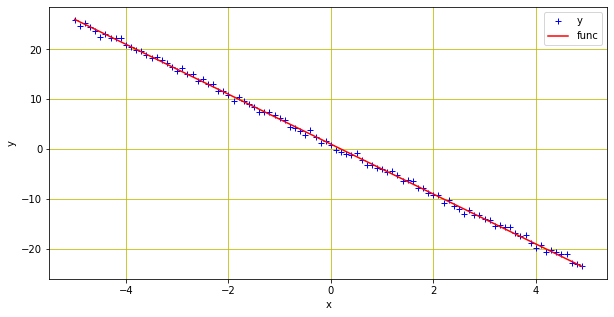

In [7]:
# Create dataset object
data_set = Build_Data()

# Plot and visualizing the data points
plt.figure(figsize=(10, 5))
plt.plot(data_set.x.numpy(), data_set.y.numpy(), 'b+', label = 'y')
plt.plot(data_set.x.numpy(), data_set.func.numpy(), 'r', label = 'func')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid('True', color='y')
plt.show()

Now let's train a simple linear layer using both optimisers and plot the losses.

_Don't worry if this all seems unfamiliar to you. It'll make more sense once you've gone through the PyTorch Crash Course notebook_

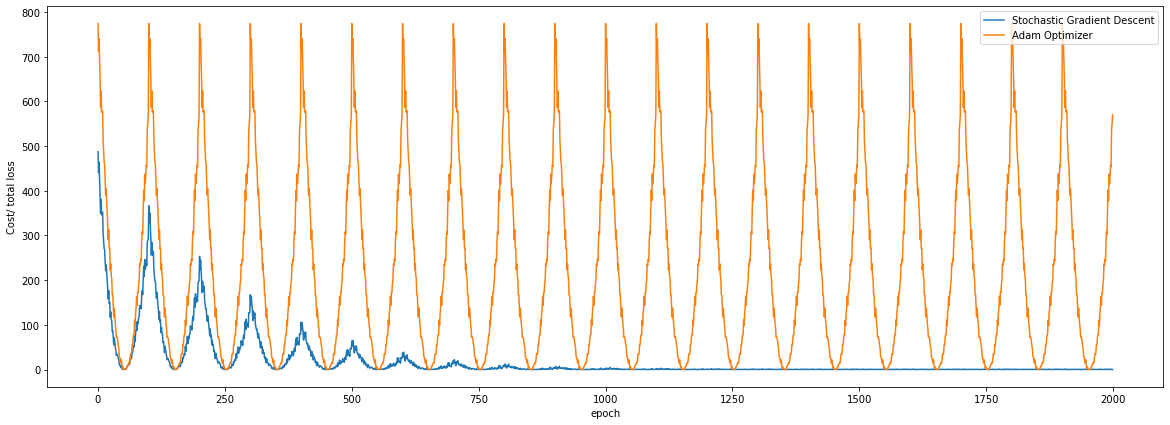

In [9]:

model = torch.nn.Linear(1, 1)
criterion = torch.nn.MSELoss()

# Creating Dataloader object
trainloader = DataLoader(dataset = data_set, batch_size=1)

# define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

loss_SGD = []
n_iter = 20

for i in range(n_iter):
    for x, y in trainloader:
        # making a prediction in forward pass
        y_hat = model(x)
        # calculating the loss between original and predicted data points
        loss = criterion(y_hat, y)
        # store loss into list
        loss_SGD.append(loss.item())
        # zeroing gradients after each iteration
        optimizer.zero_grad()
        # backward pass for computing the gradients of the loss w.r.t to learnable parameters
        loss.backward()
        # updating the parameters after each iteration
        optimizer.step()

model = torch.nn.Linear(1, 1)
loss_Adam = []
for i in range(n_iter):
    for x, y in trainloader:
        # making a prediction in forward pass
        y_hat = model(x)
        # calculating the loss between original and predicted data points
        loss = criterion(y_hat, y)
        # store loss into list
        loss_Adam.append(loss.item())
        # zeroing gradients after each iteration
        optimizer.zero_grad()
        # backward pass for computing the gradients of the loss w.r.t to learnable parameters
        loss.backward()
        # updating the parameters after each iteration
        optimizer.step()

plt.figure(figsize=(20, 7))
plt.plot(loss_SGD,label = "Stochastic Gradient Descent")
plt.plot(loss_Adam,label = "Adam Optimizer")
plt.xlabel('epoch')
plt.ylabel('Cost/ total loss')
plt.legend()
plt.show()

You can see that SGD converges faster than Adam in the above examples. 

This is because we are training a linear regression model, in which the algorithm provided by Adam is overkill.

So, "the best optimiser" depends on the nature and complexity of your problem.

That said, here is a comparison of optimizers based on Aurélien Géron's book "Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems"

<div style="text-align: center"><img src="optimizers.png" width="600"/></div>


---

# Putting It All Together

We now have every ingredient: tensors, autograd, layers, activations, losses and optimisers.
Time for the main event — a real multi-layer network on a real dataset: **MNIST**,
70,000 images of handwritten digits. This is the "hello world" of deep learning.

# 5. Multi-Layer Network
We'll also look at:
- using GPUs
- using existing Datasets
- loading data with the DataLoader
- using Batches
- applying Transforms
- doing Model Evaluation


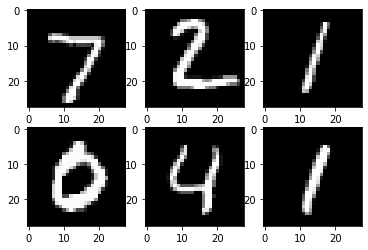

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Device configuration
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Hyper-parameters
input_size = 784 # 28x28
hidden_size = 500
num_classes = 10 # coz we have 10 digits
num_epochs = 2 #to keep it short
batch_size = 100
learning_rate = 0.001

# MNIST dataset - already included in torchvision and has train/test split
train_dataset = torchvision.datasets.MNIST(root='./data',
                                           train=True,
                                           transform=transforms.ToTensor(), #coz images come in PIL format
                                           download=True)

test_dataset = torchvision.datasets.MNIST(root='./data',
                                          train=False,
                                          transform=transforms.ToTensor())

# Data loader - provides optimised way to iterate through the dataset
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

# Just to show you how a dataloader works
# we can iterate through the dataset using the dataloader
examples = iter(test_loader)
example_data, example_targets = next(examples) # x and y (i.e. images and labels)

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(example_data[i][0], cmap='gray')
plt.show()

The network we're trying to create looks as follows

![The Neural Network Architecture](mnist_nn.png)

Let's create it and train it

In [ ]:
# Fully connected neural network with one hidden layer
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes): #only needs self, but we can add other arguments
        super(NeuralNet, self).__init__()
        self.l1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        # no activation and no softmax at the end - coz our specific loss function (CrossEntropyLoss) required raw values
        return out

model = NeuralNet(input_size, hidden_size, num_classes).to(device) #push model to GPU

# Loss and optimizer
criterion = nn.CrossEntropyLoss() #coz multi-class classification
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
n_total_steps = len(train_loader) # number of batches
# 60000 images, batch size = 100 -> 600 steps
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader): #batch by batch
        # origin shape: [100, 1, 28, 28]
        # resized: [100, 784]
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)
        #! remember to push data to GPU as well

        # Forward pass and loss calculation
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if (i+1) % 100 == 0:
            print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

Epoch [1/2], Step [100/600], Loss: 0.3522
Epoch [1/2], Step [200/600], Loss: 0.2665
Epoch [1/2], Step [300/600], Loss: 0.1811
Epoch [1/2], Step [400/600], Loss: 0.1902
Epoch [1/2], Step [500/600], Loss: 0.1613
Epoch [1/2], Step [600/600], Loss: 0.1694
Epoch [2/2], Step [100/600], Loss: 0.1548
Epoch [2/2], Step [200/600], Loss: 0.1490
Epoch [2/2], Step [300/600], Loss: 0.1055
Epoch [2/2], Step [400/600], Loss: 0.1372
Epoch [2/2], Step [500/600], Loss: 0.1236
Epoch [2/2], Step [600/600], Loss: 0.0928


Now let's test in on the test dataset

In [75]:
# Test the model: we don't need to compute gradients
with torch.no_grad():
    n_correct = 0
    n_samples = len(test_loader.dataset)

    for images, labels in test_loader:
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)

        outputs = model(images)

        # max returns (output_value ,index)
        _, predicted = torch.max(outputs, 1)
        n_correct += (predicted == labels).sum().item()

    acc = n_correct / n_samples
    print(f'Accuracy of the network on the {n_samples} test images: {100*acc} %')

Accuracy of the network on the 10000 test images: 96.72 %


## Saving The Model

In [78]:
# Print model's state_dict
print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

Model's state_dict:
l1.weight 	 torch.Size([500, 784])
l1.bias 	 torch.Size([500])
l2.weight 	 torch.Size([10, 500])
l2.bias 	 torch.Size([10])


if you're gonna use it for inference, you just need the model weights & biases

In [79]:
PATH = 'inference_model.pth'
torch.save(model.state_dict(), PATH)

And to load it and use it

In [ ]:
# model = TheModelClass(*args, **kwargs)
model = NeuralNet(input_size, hidden_size, num_classes).to(device) # same arguments as we used for training - mode has to declared beforehand (as above)
model.load_state_dict(torch.load(PATH, weights_only=True)) # load the weights
model.eval() # set the model to evaluation mode

NeuralNet(
  (l1): Linear(in_features=784, out_features=500, bias=True)
  (relu): ReLU()
  (l2): Linear(in_features=500, out_features=10, bias=True)
)

but, if you want to save it as a general checkpoint for inference and/or resuming training


In [ ]:
#minimum required parameters to save
torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
            # ... plus any other parameters you want to save
            }, PATH)

That's all for today.

Next week, we'll look at:

- Using train and test functions to automatically 
	- Log losses for easy plotting
	- Create checkpoints so you can continue training a model afterwards
- Tips for improving model performance
	- Interpreting Train vs Validation Curves
	- Regularization (e.g. Use of Dropout)
	- Comparing different activation functions
	- Adding Layers vs Neurons etc.
- Building a network layer by layer first to understand dimensions
- Working with other layer types (CNNs, maybe LSTMs) and architectures (e.g. Autoencoders)

*weight initialisation*

and much more...

---

# Day 1 Recap & Exercises

**What you built today:** a complete deep learning pipeline — data loading, a multi-layer network,
a training loop, evaluation, and model saving. Every model you build this week (CNNs, LSTMs,
autoencoders) follows this exact same pattern; only the architecture changes.

### Exercises

1. **Wider vs deeper.** Change `hidden_size` from 500 to 50 and retrain. Then instead add a *second*
   hidden layer (784 → 500 → 100 → 10). How does test accuracy change in each case?
2. **Activation swap.** Replace `nn.ReLU()` with `nn.Sigmoid()` in the MNIST network. Train for the
   same number of epochs. Which converges faster, and why? (Hint: think back to the vanishing
   gradient discussion.)
3. **Optimiser race.** Train the MNIST network once with `torch.optim.SGD` and once with
   `torch.optim.Adam`, same learning rate. Plot both loss histories on one chart.
4. **Break it on purpose.** Set the learning rate to `10`. What happens to the loss? Now set it to
   `0.0000001`. What happens? Keep these observations in mind — **tomorrow is all about tuning.**

### Tomorrow: Day 2

You can now *train* a model. But what separates a decent model from a great one isn't magic — it's
methodical tuning. Tomorrow we learn to read loss curves like a story, navigate hyperparameter space,
and debug models that refuse to converge.